# Estatística 1 - Aula prática 4_1 em Python

## UNIDADE 4: Testes de hipóteses paramétricos e intervalos de confiança

### Seção 4.1: One Sample Test

By Jose P. Leitão

#### Teste de hipótese para comparar a média de uma variável com outro valor hipotético e Intervalo de confiança para a média usando a distribuição (Z)

In [36]:
%matplotlib inline

# Importar bibliotecas
import numpy as np

import pandas as pd

from scipy.stats import norm, t, kstest, ttest_1samp, chi2

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline

# Define o formato de saída para SVG
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

import warnings
warnings.filterwarnings('ignore')

Este é um teste e intervalo de confiança para grandes amostras.
Vamos utilizar a base de dados "qi_unpaired" que tem dados de
"QI" de alunos

In [2]:
# Carregando a base de dados
qi_unpaired = pd.read_csv("qi_unpaired.csv")

In [3]:
# Vamos calcular a media e o desvio padrao da variavel "qi", 
# de toda amostra
qi_media = qi_unpaired['qi'].mean()
print(qi_media)

107.875


In [4]:
# Calculando as estatisticas descritivas por grupo, garotos e garotas:
qi_unpaired.groupby(['group']).describe()

qi                                                        
       count     mean        std   min     25%    50%     75%    max
group                                                               
boy    120.0  105.575  15.177749  73.0   94.75  105.0  117.25  140.0
girl   120.0  110.175  15.181071  72.0  100.75  112.0  119.00  145.0

In [ ]:
# Calculando o desvio padrão de toda amostra:
qi_std = qi_unpaired['qi'].std()
print(qi_std)

15.321963069439086


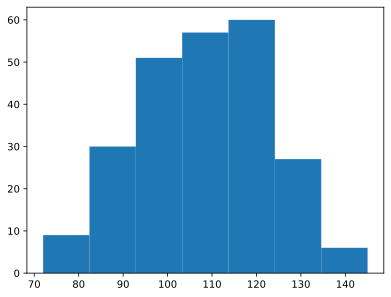

In [6]:
# Vamos gerar um histograma:
num_bins = 7
plt.hist(qi_unpaired['qi'], bins=num_bins)
plt.show()

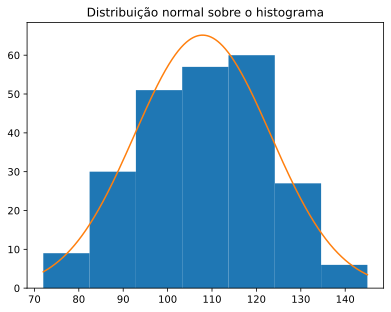

In [30]:
# Vamos plotar a curva normal sobre o histograma:

# vetor equivalente a qi_unpaired$qi
data = qi_unpaired["qi"].values

# parâmetros da normal ajustada
mu = np.mean(data)
sigma = np.std(data, ddof=1)

# histograma (prob=FALSE → frequência absoluta)
num_bins = 7
plt.hist(data, bins=num_bins, density=False)

# eixo x para a curva
x = np.linspace(min(data), max(data), 1000)

# curva normal ajustada
y = norm.pdf(x, mu, sigma)

# como o histograma está em frequência absoluta,
# precisamos escalar a densidade:
bin_width = (max(data) - min(data)) / num_bins
y_scaled = y * len(data) * bin_width

plt.plot(x, y_scaled)

plt.title("Distribuição normal sobre o histograma")
plt.show()

Para uma amostra ou grupo nao é necessário testar se a variância é constante isto porque basta que a amostra/população seja normalmente distribuida para que a variância seja bem comportada. Se soubermos que a amostra provem de uma populção normalmente distribuida nao é necessário ou obrigatório testar a normalidade, mas é prudente.

In [8]:
# Executanto teste de normalidade de Kolmogorov-Smirnov
data = qi_unpaired["qi"].values

mu = np.mean(data)
sigma = np.std(data, ddof=1)

ks_stat, p_value = kstest(data, 'norm', args=(mu, sigma))

print("KS statistic:", ks_stat)
print("p-value:", p_value)

KS statistic: 0.05612033465135691
p-value: 0.42095540035032364


Regra de bolso: Como o p-value é superior a **0.05**, a variável "qi" é normalmente distribuida 

Ressalta-se que se não fosse identificada normalidade deveriamos utilizar um teste equivalente não paramétrico, portanto, não usariamos o teste "Z" nem "t"

### Executando o teste de z para uma amostra com o valor hipotético de 110 que é o "qi" médio das garotas 

#### Hipóteses:
- H0: a média do "qi" geral é estatisticamente igual a 110
- Ha: a média do "qi" geral nao é estatisticamente igual a 110

In [ ]:
# Realizando o z-test para as hipóteses acima

data = qi_unpaired["qi"].values

# O que será havaliado
mu0 = 110 # QI médio das garotas

sigma = np.std(data, ddof=1)  # Obter o desvio padrão
n = len(data) # tamanho da amostra

# Estatística Z
z_stat = (np.mean(data) - mu0) / (sigma / np.sqrt(n))

# p-valor bilateral
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

# Intervalo de confiança
alpha = 0.05 # 5% de significância
z_crit = norm.ppf(1 - alpha/2) # teste bi-caudal
margin = z_crit * sigma / np.sqrt(n)

ci_lower = np.mean(data) - margin
ci_upper = np.mean(data) + margin

print(f"Z statistic: {z_stat:.4f}")
print(f"p-value: {p_value:.4f}")
print(f"95% CI: {ci_lower:.2f}, {ci_upper:.2f}")
print(f"Média: {np.mean(data):.2f}" )

Z statistic: -2.1486
p-value: 0.0317
95% CI: 105.94, 109.81
Média: 107.88


### Intervalo de confiança
Isso quer dizer que o "qi" médio geral vai variar entre 105,94
e 109,81, com uma média de 107,88, com 95% de confiança ou 5%
de significância

### Resultado do teste da média:
Valor da Estatística z = -2,1486
Confrontamos esse valor com o valor tabelado da estatistica Z
para 95% de confiança ou 5% de significância (usamos isso para
obter o valor tabelado, conforme comando abaixo)

In [11]:
# Obtendo os valores tabelados da estatistica Z:
q1 = norm.ppf(0.025)
q2 = norm.ppf(0.975)
print(q1) # os 2,5% da cauda inferior
print(q2) # os 2,5% da cauda superior

-1.9599639845400545
1.959963984540054


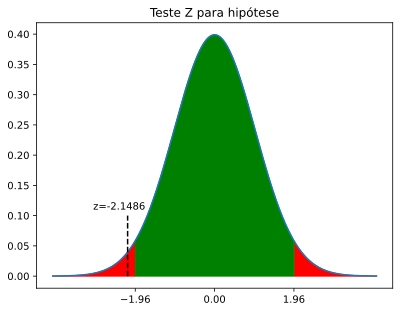

In [29]:
# Construindo a curva normal:
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)

plt.plot(x, y)
plt.fill_between(x, y, where=((x < q1) | (x > q2)), color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), color='green')
plt.vlines(-2.1486, 0, 0.10, linestyles="--", colors='black')
plt.xticks([q1, 0, q2])
plt.text(-3, 0.11, 'z=-2.1486')
plt.title("Teste Z para hipótese")
plt.show()

Como a estatística z calculada (-2.1486) é menor que a 
estatística tabelada (-1.96), este valor se situa na região
de rejeição de H0, portanto rejeitamos a hipótese (H0) de que
o valor verdadeiro da média da variavel "qi" é 
estatisticamente igual a 110 ("qi" médio das garotas).

Ressalta-se que se o valor da estatística z calculada (no
resultado do teste) fosse maior que 1.96 (valor tabelado) o
resultado seria o mesmo em termos de interpretação do teste. 

Mas, se a estatística z calculada (no resultado do teste) se
situasse entre -1.96 e 1.96 (valor tabelado), não rejeitariamos
H0.

Se este fosse o caso, não poderiamos rejeitar que a média da
variável "qi" seria estatisticamente igual a 110, com 95% de
confiançaa ou 5% de significância.

#### Teste de hipótese para comparar a média de uma variável com outro valor hipotético e Intervalo de confiança para a média   usando a Distribuição "t"   

#### Este é um teste e intervalo de confiança para pequenas amostras

In [3]:
# Vamos utilizar a base de dados "mw_weight", uma amostra com 
# pesos de homens e mulheres 
# Carregando a base de dados
mw_weight = pd.read_csv('mw_weight.csv')

In [4]:
# Exemplo para a variavel "weight", peso das mulheres na base de
# dados "mw_weight"
mw_weight.head()

,group,weight
0,Woman,38.9
1,Woman,61.2
2,Woman,73.3
3,Woman,21.8
4,Woman,63.4


In [5]:
# Primeiro, vamos ver estatisticas descritivas do dataset
mw_weight.groupby(['group']).describe()

weight                                                    
       count       mean        std   min   25%   50%   75%   max
group                                                           
Man      9.0  68.988889   9.375426  60.0  62.4  67.3  73.3  89.4
Woman    9.0  52.100000  15.596714  21.8  48.4  48.8  63.4  73.3

In [6]:
# Agora vamos separar as mulheres em outro objeto:
pesow = mw_weight.query("group  == 'Woman'")['weight'].to_numpy()

In [9]:
# Vamos calcular algumas estatisticas descritivas das mulheres
print(pesow.mean()) # Média
print(pesow.std()) # desvio padrao  

52.099999999999994
14.704723353021263


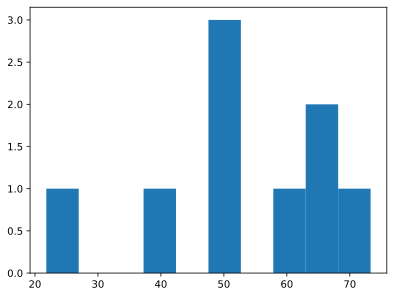

In [32]:
# Vamos gerar um histograma
num_bins = 10
plt.hist(pesow, bins=num_bins)
plt.show()

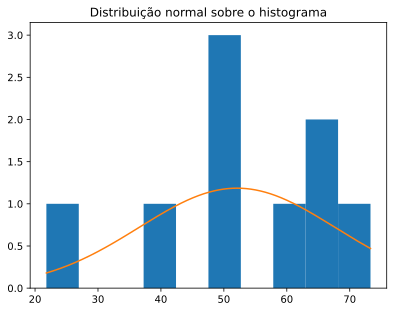

In [33]:
# Vamos plotar a curva normal sobre o histograma
# vetor equivalente a qi_unpaired$qi
data = pesow

# parâmetros da normal ajustada
mu = np.mean(data)
sigma = np.std(data, ddof=1)

# histograma (prob=FALSE → frequência absoluta)
num_bins = 10
plt.hist(data, bins=num_bins, density=False)

# eixo x para a curva
x = np.linspace(min(data), max(data), 1000)

# curva normal ajustada
y = norm.pdf(x, mu, sigma)

# como o histograma está em frequência absoluta,
# precisamos escalar a densidade:
bin_width = (max(data) - min(data)) / num_bins
y_scaled = y * len(data) * bin_width

plt.plot(x, y_scaled)

plt.title("Distribuição normal sobre o histograma")
plt.show()

In [13]:
# Executanto teste de normalidade de Kolmogorov-smirnov:
data = pesow

mu = np.mean(data)
sigma = np.std(data, ddof=1)

ks_stat, p_value = kstest(data, 'norm', args=(mu, sigma))

print("KS statistic:", ks_stat)
print("p-value:", p_value)

KS statistic: 0.18401717249809046
p-value: 0.8694672394798189


Como o p-value é superior a 0.05, a variável "weight" para as  mulheres é normalmente distribuida

Vamos executar o teste de t para a média dos pesos das mulheres comparando com um valor hipotético de 69 que é o peso dos homens

Hipóteses:
- H0: A media do peso das mulheres é estatisticamente igual a 69
- Ha: A media do peso das mulheres nao é estatisticamente igual a 69

In [21]:
# t-test
# -----------------------------
# Configuração
# -----------------------------
alpha = 0.05
confidence = 0.95
mu_0 = 69

data = pesow

n = len(data)
mean = np.mean(data)
std = np.std(data, ddof=1)

t_stat, p_value = ttest_1samp(data, mu_0)

# Intervalo de confiança
df = n - 1
t_crit = t.ppf((1 + confidence) / 2, df)
margin_error = t_crit * std / np.sqrt(n)

ci_lower = mean - margin_error
ci_upper = mean + margin_error

print("\nResultado do t-test:")
print(f"Graus de liberdade: {n-1}")
print(f"Estatística t: {t_stat:.4f}")
print("p-valor:", p_value)

print(f"\nIntervalo de Confiança {int(confidence*100)}% para a média: {mean:.2f}")
print(f"({ci_lower:.2f}, {ci_upper:.2f})")


Resultado do t-test:
Graus de liberdade: 8
Estatística t: -3.2507
p-valor: 0.011689093850799285

Intervalo de Confiança 95% para a média: 52.10
(40.11, 64.09)


In [ ]:
# Resultado do intervalo de confiança:
# Isso quer dizer que a media dos pesos das mulheres vai variar
# entre 40.11 e 64.09, com uma media de 52.10, com 95% de 
# confianca ou 5% de significancia.

# Resultado para o teste da media:
# Valor da Estatistica: t = -3.2507, com 8 graus de liberdade

# Confrontamos esse valor com o valor tabelado da estatistica t
# para 95% de confianca ou 5% de significancia (usamos isso para
# obter os valores tabelados, conforme comandos abaixo)

In [ ]:
q1 = t.ppf(0.025, df=8) # cauda inferior
q2 = t.ppf(0.975, df=8) # cauda superior
print(f"{q1:.2f}")
print(f"{q2:.2f}")

-2.31
2.31


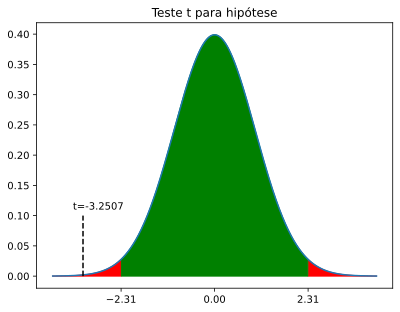

In [ ]:
# Vamos construir o grafico
mu = 0
sigma = 1
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 1000)
y = norm.pdf(x, mu, sigma)
q1 = -2.31
q2 = 2.31

plt.plot(x, y)
plt.fill_between(x, y, where=((x < q1) | (x > q2)), color='red')
plt.fill_between(x, y, where=((x >= q1) & (x <= q2) ), color='green')
plt.vlines(t_stat, 0, 0.10, linestyles="--", colors='black')
plt.xticks([q1, 0, q2])
plt.text(-3.5, 0.11, 't=-3.2507')
plt.title("Teste t para hipótese")
plt.show()

Como a estatística t calculada (-3.2507) é menor que a estatística tabelada (-2,31), portanto o valor de -3.2507 se
encontra na região de rejeição.
Sendo assim, rejeitamos a hipótese (H0) de que o valor verdadeiro da média é estatisticamente igual a 69,00 (peso 
dos homens).

Ressalta-se que caso o valor da estatística t calculada (no resultado do teste) fosse maior que 2.31 o resultado seria o
mesmo em termos de interpretação do teste. 

Mas, se a estatística t calculada (no resultado do teste) se situasse entre -2.31 e 2.31 (valor tabelado) não rejeitariamos
H0. Neste caso, poderiamos considerar que a média da variável seria estatisticamente igual a 69,00 com 95% de confiança ou
5% de significância. 

### Intervalo de confiança para o desvio padrão 

In [38]:
# Calculando o intervalo de confianca do desvio padrao para a
# variavel peso das mulheres - mesmo dataset do exercicio 
# anterior:
# Dados
data = pesow

# Parâmetros
alpha = 0.05
n = len(data)
df = n - 1

# Estatísticas amostrais
s2 = np.var(data, ddof=1)

# Quantis da qui-quadrado
chi2_lower = chi2.ppf(alpha/2, df)
chi2_upper = chi2.ppf(1 - alpha/2, df)

# Intervalo para variância
var_lower = (df * s2) / chi2_upper
var_upper = (df * s2) / chi2_lower

# Intervalo para desvio padrão
std_lower = np.sqrt(var_lower)
std_upper = np.sqrt(var_upper)

print("IC 95% para o desvio padrão:")
print(f"{std_lower:.2f}, {std_upper:.2f}")

IC 95% para o desvio padrão:
10.53, 29.88


In [ ]:
# Resultado:
# Isso quer dizer que o desvio padrao da variavel "weight" varia
# entre 10,53 e 29,88, com media de 15,60, com 95% de confianca
# ou 5% de significancia em um teste bicaudal